# <wc_2022.csv> Exploration:
- Downloaded from <https://www.kaggle.com/datasets/die9origephit/fifa-world-cup-2022-complete-dataset/data> on 6/24/26
- 64 x 88 table; each row is a game from the 2022 World Cup in Qatar
- The math on the game totals checks out. 32 teams; in the group stage, each plays 3 games, so 32 x 3 = 96; however, you have to divide that by 2 because each game features two teams, so that's 48 total games. In the knockout rounds, there are 15 elimination games (16 teams enter the knockout round, 15 are eliminated) + 1 consolation game for 3rd place. So: 48 + 15 + 1 = 64 total games.

In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
wc_2022 = pd.read_csv('wc_2022.csv')
wc_2022.head()

,team1,team2,possession team1,possession team2,possession in contest,number of goals team1,number of goals team2,date,hour,category,...,penalties scored team1,penalties scored team2,goal preventions team1,goal preventions team2,own goals team1,own goals team2,forced turnovers team1,forced turnovers team2,defensive pressures applied team1,defensive pressures applied team2
0,QATAR,ECUADOR,42%,50%,8%,0,2,20 NOV 2022,17 : 00,Group A,...,0,1,6,5,0,0,52,72,256,279
1,ENGLAND,IRAN,72%,19%,9%,6,2,21 NOV 2022,14 : 00,Group B,...,0,1,8,13,0,0,63,72,139,416
2,SENEGAL,NETHERLANDS,44%,45%,11%,0,2,21 NOV 2022,17 : 00,Group A,...,0,0,9,15,0,0,63,73,263,251
3,UNITED STATES,WALES,51%,39%,10%,1,1,21 NOV 2022,20 : 00,Group B,...,0,1,7,7,0,0,81,72,242,292
4,ARGENTINA,SAUDI ARABIA,64%,24%,12%,1,2,22 NOV 2022,11 : 00,Group C,...,1,0,4,14,0,0,65,80,163,361


In [3]:
team_list = wc_2022['team1'].unique()

In [4]:
team_results_2022 = []
for team in team_list:
    games = 0
    goals_scored = 0
    goals_allowed = 0
    for i in range(wc_2022.shape[0]):
        if wc_2022.iloc[i, 0]==team:
            games += 1
            goals_scored += wc_2022.iloc[i, 5]
            goals_allowed += wc_2022.iloc[i, 6]
        elif wc_2022.iloc[i, 1]==team:
            games += 1
            goals_scored += wc_2022.iloc[i, 6]
            goals_allowed += wc_2022.iloc[i, 5]
    score_average = (goals_scored/games - goals_allowed/games)
    team_results_2022.append([team, games, goals_scored, goals_allowed, score_average])
team_results_2022

[['QATAR', 3, np.int64(1), np.int64(7), np.float64(-2.0)],
 ['ENGLAND', 5, np.int64(13), np.int64(4), np.float64(1.8)],
 ['SENEGAL', 4, np.int64(5), np.int64(7), np.float64(-0.5)],
 ['UNITED STATES', 4, np.int64(3), np.int64(4), np.float64(-0.25)],
 ['ARGENTINA', 7, np.int64(15), np.int64(8), np.float64(1.0)],
 ['DENMARK', 3, np.int64(1), np.int64(3), np.float64(-0.6666666666666667)],
 ['MEXICO', 3, np.int64(2), np.int64(3), np.float64(-0.33333333333333337)],
 ['FRANCE', 7, np.int64(16), np.int64(8), np.float64(1.1428571428571428)],
 ['MOROCCO', 7, np.int64(6), np.int64(5), np.float64(0.1428571428571428)],
 ['GERMANY', 3, np.int64(6), np.int64(5), np.float64(0.33333333333333326)],
 ['SPAIN', 4, np.int64(9), np.int64(3), np.float64(1.5)],
 ['BELGIUM', 3, np.int64(1), np.int64(2), np.float64(-0.3333333333333333)],
 ['SWITZERLAND', 4, np.int64(5), np.int64(9), np.float64(-1.0)],
 ['URUGUAY', 3, np.int64(2), np.int64(2), np.float64(0.0)],
 ['PORTUGAL', 5, np.int64(12), np.int64(6), np.floa

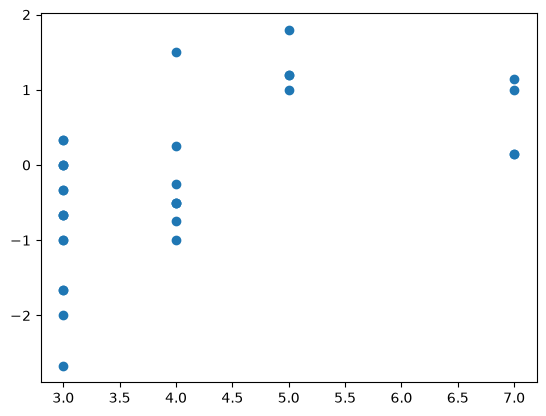

In [5]:
games_played = []
for i in range(len(team_results_2022)):
    games_played.append(team_results_2022[i][1])
score_average = []
for i in range(len(team_results_2022)):
    score_average.append(team_results_2022[i][4])
plt.scatter(games_played, score_average)

In [6]:
fifa_rankings = pd.read_csv('fifa_ranking-2024-06-20.csv')
fifa_rankings['rank_date'].unique

<bound method Series.unique of 0        1992-12-31
1        1992-12-31
2        1992-12-31
3        1992-12-31
4        1992-12-31
            ...    
67467    2024-06-20
67468    2024-06-20
67469    2024-06-20
67470    2024-06-20
67471    2024-06-20
Name: rank_date, Length: 67472, dtype: str>

In [7]:
rankings_2022 = fifa_rankings[fifa_rankings['rank_date']=='2022-10-06']
rankings_2022.head()

,rank,country_full,country_abrv,total_points,previous_points,rank_change,confederation,rank_date
64947,197.0,Tonga,TGA,861.81,861.81,0,OFC,2022-10-06
64948,102.0,Madagascar,MAD,1200.74,1193.78,-3,CAF,2022-10-06
64949,74.0,El Salvador,SLV,1330.51,1333.48,3,CONCACAF,2022-10-06
64950,73.0,Congo DR,COD,1333.92,1332.84,1,CAF,2022-10-06
64951,21.0,Serbia,SRB,1563.62,1549.53,-4,UEFA,2022-10-06


In [8]:
edited_teams = team_list
edited_teams[3] = 'USA'
edited_teams[25] = 'IR IRAN'


In [9]:
print("The last FIFA world rankings before the 2022 World Cup were posted on October 6th.")
print('Going into the 2022 World Cup, the team rankings were as follows:')
ranking_list=[]
for team in edited_teams:
    for i in range(rankings_2022.shape[0]):
        if rankings_2022.iloc[i, 1].casefold() == team.casefold():
            print(f'{team}: {rankings_2022.iloc[i, 0]}')
            ranking_list.append(rankings_2022.iloc[i, 0])

The last FIFA world rankings before the 2022 World Cup were posted on October 6th.
Going into the 2022 World Cup, the team rankings were as follows:
QATAR: 50.0
ENGLAND: 5.0
SENEGAL: 18.0
USA: 16.0
ARGENTINA: 3.0
DENMARK: 10.0
MEXICO: 13.0
FRANCE: 4.0
MOROCCO: 22.0
GERMANY: 11.0
SPAIN: 7.0
BELGIUM: 2.0
SWITZERLAND: 15.0
URUGUAY: 14.0
PORTUGAL: 9.0
BRAZIL: 1.0
WALES: 19.0
NETHERLANDS: 8.0
TUNISIA: 30.0
POLAND: 26.0
JAPAN: 24.0
CROATIA: 12.0
CAMEROON: 43.0
KOREA REPUBLIC: 28.0
ECUADOR: 44.0
IR IRAN: 20.0
AUSTRALIA: 38.0
SAUDI ARABIA: 51.0
CANADA: 41.0
COSTA RICA: 31.0
GHANA: 61.0
SERBIA: 21.0


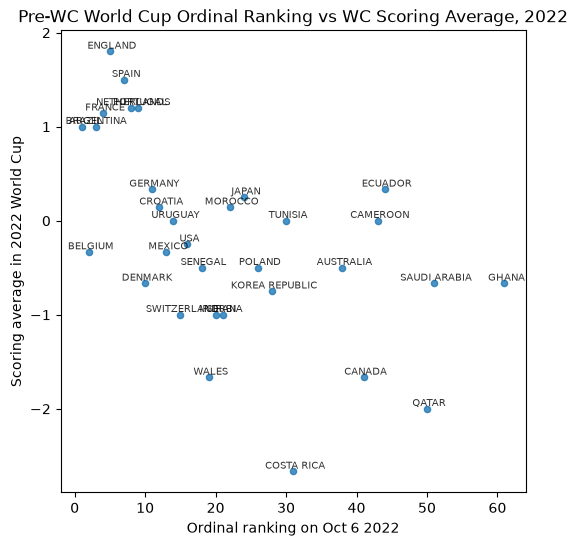

In [59]:
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(ranking_list, score_average, s=20, alpha = 0.8)
for i in range(len(edited_teams)):
    ax.annotate(edited_teams[i], xy=(ranking_list[i], score_average[i]), xytext=(1.5,2.0),
                ha='center', textcoords='offset points', size=7, alpha=0.8)
ax.set_xlabel('Ordinal ranking on Oct 6 2022')
ax.set_ylabel('Scoring average in 2022 World Cup')
ax.set_title('Pre-WC World Cup Ordinal Ranking vs WC Scoring Average, 2022')
plt.show()


In [76]:
ordinal_data_matrix = np.array(ranking_list)
ones = np.ones((len(ranking_list), 1))
ordinal_data_matrix = np.transpose(np.vstack((np.array(ranking_list), np.ones((len(ranking_list))))))
ordinal_data_matrix

array([[50.,  1.],
       [ 5.,  1.],
       [18.,  1.],
       [16.,  1.],
       [ 3.,  1.],
       [10.,  1.],
       [13.,  1.],
       [ 4.,  1.],
       [22.,  1.],
       [11.,  1.],
       [ 7.,  1.],
       [ 2.,  1.],
       [15.,  1.],
       [14.,  1.],
       [ 9.,  1.],
       [ 1.,  1.],
       [19.,  1.],
       [ 8.,  1.],
       [30.,  1.],
       [26.,  1.],
       [24.,  1.],
       [12.,  1.],
       [43.,  1.],
       [28.,  1.],
       [44.,  1.],
       [20.,  1.],
       [38.,  1.],
       [51.,  1.],
       [41.,  1.],
       [31.,  1.],
       [61.,  1.],
       [21.,  1.]])

In [77]:
ordinal_coefs = np.linalg.lstsq(ordinal_data_matrix, score_average)
ordinal_coefs

(array([-0.03536556,  0.5790115 ]),
 array([23.52532685]),
 np.int32(2),
 array([152.05275922,   3.31034961]))

In [81]:
print(f'For the ordinal rankings, the regression residual is {ordinal_coefs[1]}')

For the ordinal rankings, the regression residual is [23.52532685]


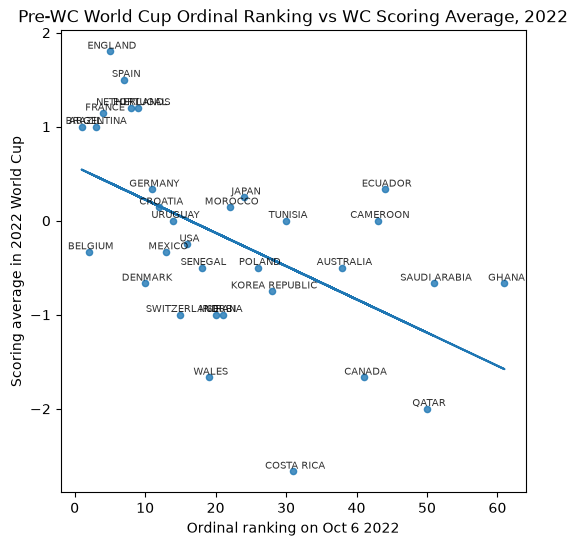

In [80]:
ord_slope, ord_intercept = ordinal_coefs[0]
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(ranking_list, score_average, s=20, alpha = 0.8)
for i in range(len(edited_teams)):
    ax.annotate(edited_teams[i], xy=(ranking_list[i], score_average[i]), xytext=(1.5,2.0),
                ha='center', textcoords='offset points', size=7, alpha=0.8)
ax.set_xlabel('Ordinal ranking on Oct 6 2022')
ax.set_ylabel('Scoring average in 2022 World Cup')
ax.set_title('Pre-WC World Cup Ordinal Ranking vs WC Scoring Average, 2022')
ax.plot(ranking_list, ord_slope*np.array(ranking_list) + ord_intercept)
plt.show()

In [60]:
print('Looking instead at total ranking points rather than the ordinal ranking:')
rpoints_list=[]
for team in edited_teams:
    for i in range(rankings_2022.shape[0]):
        if rankings_2022.iloc[i, 1].casefold() == team.casefold():
            print(f'{team}: {rankings_2022.iloc[i, 3]}')
            rpoints_list.append(rankings_2022.iloc[i, 3])

Looking instead at total ranking points rather than the ordinal ranking:
QATAR: 1439.89
ENGLAND: 1728.47
SENEGAL: 1584.38
USA: 1627.48
ARGENTINA: 1773.88
DENMARK: 1666.57
MEXICO: 1644.89
FRANCE: 1759.78
MOROCCO: 1563.5
GERMANY: 1650.21
SPAIN: 1715.22
BELGIUM: 1816.71
SWITZERLAND: 1635.92
URUGUAY: 1638.71
PORTUGAL: 1676.56
BRAZIL: 1841.3
WALES: 1569.82
NETHERLANDS: 1694.51
TUNISIA: 1507.54
POLAND: 1548.59
JAPAN: 1559.54
CROATIA: 1645.64
CAMEROON: 1471.44
KOREA REPUBLIC: 1530.3
ECUADOR: 1464.39
IR IRAN: 1564.61
AUSTRALIA: 1488.72
SAUDI ARABIA: 1437.78
CANADA: 1475.0
COSTA RICA: 1503.59
GHANA: 1393.0
SERBIA: 1563.62


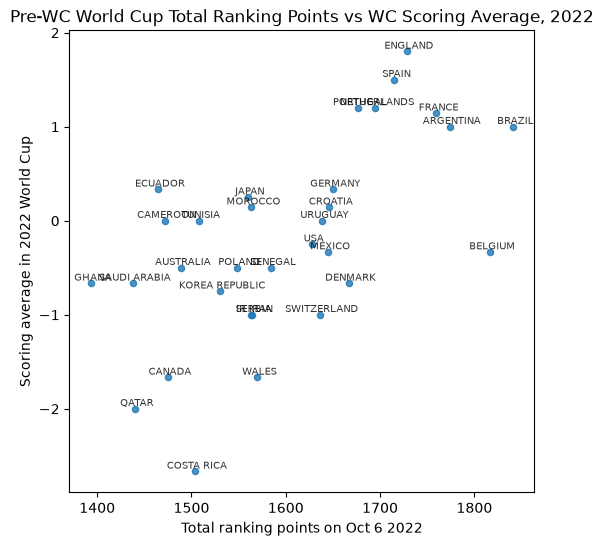

In [61]:
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(rpoints_list, score_average, s=20, alpha = 0.8)
for i in range(len(edited_teams)):
    ax.annotate(edited_teams[i], xy=(rpoints_list[i], score_average[i]), xytext=(1.5,2.0),
                ha='center', textcoords='offset points', size=7, alpha=0.8)
ax.set_xlabel('Total ranking points on Oct 6 2022')
ax.set_ylabel('Scoring average in 2022 World Cup')
ax.set_title('Pre-WC World Cup Total Ranking Points vs WC Scoring Average, 2022')
plt.show()

In [82]:
rpoints_data_matrix = np.array(rpoints_list)
ones = np.ones((len(rpoints_list), 1))
rpoints_data_matrix = np.transpose(np.vstack((np.array(rpoints_list), np.ones((len(rpoints_list))))))
rpoints_data_matrix

array([[1.43989e+03, 1.00000e+00],
       [1.72847e+03, 1.00000e+00],
       [1.58438e+03, 1.00000e+00],
       [1.62748e+03, 1.00000e+00],
       [1.77388e+03, 1.00000e+00],
       [1.66657e+03, 1.00000e+00],
       [1.64489e+03, 1.00000e+00],
       [1.75978e+03, 1.00000e+00],
       [1.56350e+03, 1.00000e+00],
       [1.65021e+03, 1.00000e+00],
       [1.71522e+03, 1.00000e+00],
       [1.81671e+03, 1.00000e+00],
       [1.63592e+03, 1.00000e+00],
       [1.63871e+03, 1.00000e+00],
       [1.67656e+03, 1.00000e+00],
       [1.84130e+03, 1.00000e+00],
       [1.56982e+03, 1.00000e+00],
       [1.69451e+03, 1.00000e+00],
       [1.50754e+03, 1.00000e+00],
       [1.54859e+03, 1.00000e+00],
       [1.55954e+03, 1.00000e+00],
       [1.64564e+03, 1.00000e+00],
       [1.47144e+03, 1.00000e+00],
       [1.53030e+03, 1.00000e+00],
       [1.46439e+03, 1.00000e+00],
       [1.56461e+03, 1.00000e+00],
       [1.48872e+03, 1.00000e+00],
       [1.43778e+03, 1.00000e+00],
       [1.47500e+03,

In [83]:
rpoints_coefs = np.linalg.lstsq(rpoints_data_matrix, score_average)
rpoints_coefs

(array([ 5.58031734e-03, -9.11658673e+00]),
 array([20.66421871]),
 np.int32(2),
 array([9.07033160e+03, 3.99282869e-01]))

In [84]:
print(f'Using ranking points, the regression residual is {rpoints_coefs[1]}')

Using ranking points, the regression residual is [20.66421871]


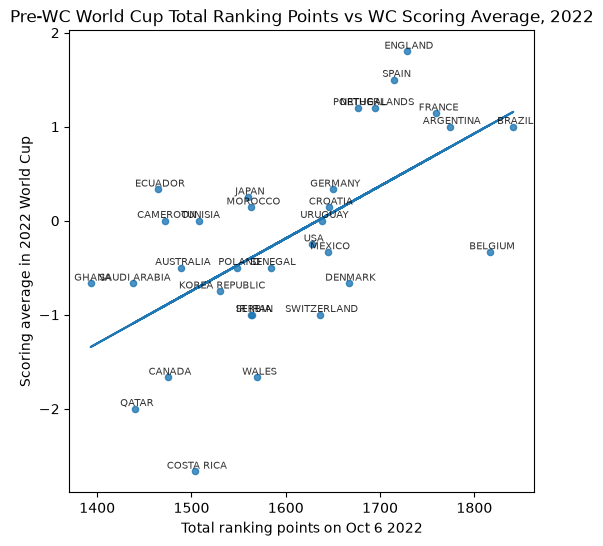

In [85]:
rpoints_slope, rpoints_intercept = rpoints_coefs[0]
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(rpoints_list, score_average, s=20, alpha = 0.8)
for i in range(len(edited_teams)):
    ax.annotate(edited_teams[i], xy=(rpoints_list[i], score_average[i]), xytext=(1.5,2.0),
                ha='center', textcoords='offset points', size=7, alpha=0.8)
ax.set_xlabel('Total ranking points on Oct 6 2022')
ax.set_ylabel('Scoring average in 2022 World Cup')
ax.set_title('Pre-WC World Cup Total Ranking Points vs WC Scoring Average, 2022')
ax.plot(rpoints_list, rpoints_slope*np.array(rpoints_list) + rpoints_intercept)
plt.show()